## Leçon 8:  Différences finies avec numpy.

#### Exemple de solution de transport diffusion-convection scalaire, la vitesse du fluide est connue, on ne solutionne pas Navier-Stokes.

#### On utilise la solution matricielle directe des équations de différences finies. 

L'équation est donc 
$$ v_x\frac {\partial C}{\partial x } +v_y \frac {\partial C}{\partial x }= D \left (\frac {\partial ^{2} C}{\partial x^{2} } +\frac {\partial ^{2} C}{\partial y^{2} }   \right)$$

On utilise des différences décentrées arrières pour la convection, donc les vitesses données doivent être positives. On ne discutera pas ici des problèmes associés au décentrage et à la stabilité des équations de diffusion-convection. Il serait toutefois assez facile d'appliquer un algorithme de décentrage de type 'upwind' qui assurerait la stabilité (sinon la précision) des équations.

L'exemple donné est adapté de Heys, Chemical and Biotechnological Engineerinc Calculations using Python 3.

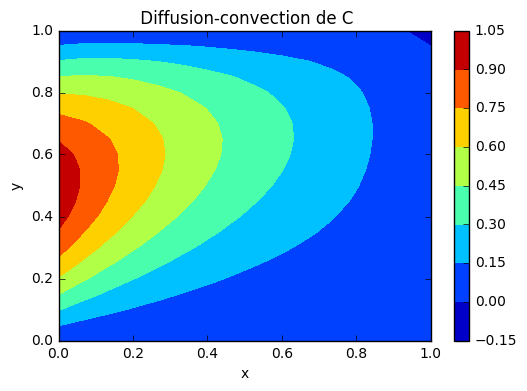

In [27]:
#
# Une fonction pour construire la matrice de D.F.
#
def differencesFinies(NPI,NPJ,aid,ajd,aic,ajc,ap,A,b):
    for i in range( 0 ,NPI):
        for j in range( 0 ,NPJ) :
            p = j*    (NPI)    + i
            pE= j*    (NPI)    + i+1           #  Construction de la matrice de différences finies A x = b
            pO= j*    (NPI)    + i-1           #  de taille (NPI x NPJ)  par (NPI x NPJ)
            pN= (j+1)*(NPI)    + i 
            pS= (j-1)*(NPI)    + i 
            if   i == 0:
                A[p,p] =1.0
                b[p]= np.sin(np.pi*y[j])
            elif i == NII:
                A[p,p]=1.0                      # conditions aux limites
                b[p]=0.0
            elif j == 0: 
                A[p,p]=1.0
                b[p]=0.0
            elif j == NIJ: 
                A[p,p]=1.0
                b[p]=0.0
            else:
                A[p,p]  = ap+aic+ajc             # matrice, points intérieurs
                A[p,pE] = aid
                A[p,pO] = aid-aic
                A[p,pN] = ajd
                A[p,pS] = ajd-ajc
                b[p]    = 0
    return A,b 
#
#
# Début du code
#
import numpy as np
from numpy.linalg import solve
import pylab
%matplotlib inline
NII     = 15        # nombre d'intervalles direction x
NIJ     = 20        # nombre d'intervalles direction y
NPI     =NII+1      # nombre de points direction x
NPJ     =NIJ+1      # nombre de points direction y
ouest = 0.0 
est   = 1.0
sud   = 0.0
nord  = 1.0
x     = np.linspace(ouest , est  ,NPI )
y     = np.linspace( sud  , nord ,NPJ )
v     = np.array([5,5])
dx    = x[1]-x[0]
dy    = y[1]-y[0]
aic   = -v[0]/dx
ajc   = -v[1]/dy
aid   = 1.0/dx**2
ajd   = 1.0/dy**2
ap   = -2.0*(aid+ajd)
X,Y   = np.meshgrid(x,y)
total = (NPI)*(NPJ)
#
#     initialisation du système
#
A     = np.zeros((total,total))
b     = np.zeros(total)
#
#     
A,b   = differencesFinies(NPI,NPJ,aid,ajd,aic,ajc,ap,A,b)
#
#
c=solve(A, b )                   #   solution directe
C=c.reshape(NPJ,NPI)             #   reconstruire la matrice pour tracer
pylab.contourf(X,Y,C)
pylab.colorbar ( )
pylab.xlabel ('x')
pylab.ylabel ('y')
Ti=' Diffusion-convection de C'
pylab.title(Ti)
pylab.show( )

### Exemple un peu plus avancé, on a ajouté un terme réactif, simplement ici une source ponctuelle, et on a aussi ajouté le décentrage du terme de convection par la méthode 'Upwind'. Pour le reste l'exemple est presque identique à celui plus haut.

$$ v_x\frac {\partial C}{\partial x } +v_y \frac {\partial C}{\partial x }= D \left (\frac {\partial ^{2} C}{\partial x^{2} } +\frac {\partial ^{2} C}{\partial y^{2} }  \right) + S $$

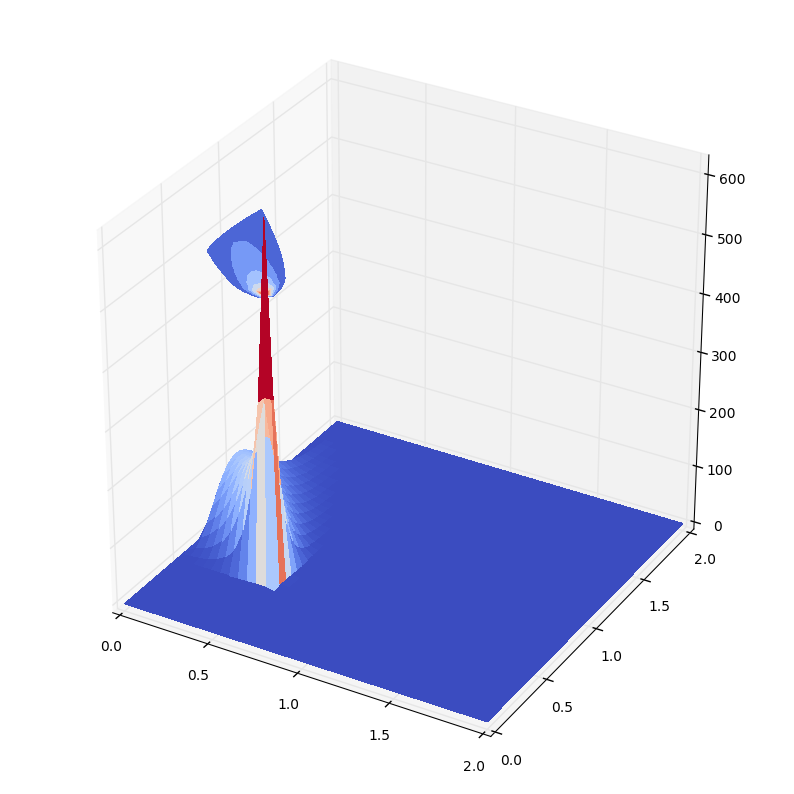

In [6]:
# -*- coding: utf-8 -*-
"""
Created on Mon Dec 19 15:17:02 2016

@author: prop2201
"""
#
# Une fonction pour construire la matrice de D.F.
#
def differencesFinies(NPI,NPJ,aid,ajd,aic,ajc,ap,A,b):
    for i in range( 0 ,NPI):
        for j in range( 0 ,NPJ) :
            p = j*    (NPI)    + i
            pE= j*    (NPI)    + i+1 #  Construction de la matrice de différences finies A x = b
            pO= j*    (NPI)    + i-1 #  de taille (NPI x NPJ)  par (NPI x NPJ)
            pN= (j+1)*(NPI)    + i 
            pS= (j-1)*(NPI)    + i 
            if   i == 0:
                A[p,p] =1.0
                b[p]= 0
            elif i == NII:
                A[p,p]=1.0                      # conditions aux limites, partout Dirichlet
                b[p]=0.0
                A[p,pO]=-1.0                    # sauf Newman à l'EST, gradient nul
            elif j == 0: 
                A[p,p]=1.0
                b[p]=0.0
            elif j == NIJ: 
                A[p,p]=1.0
                b[p]=0.0
            else:
                #   Effectuons un décentrage 'UPWIND' pour la convection
            #
            # Il est connu que numériquement, un décentrage solutionne le 
            # problème de l'instabilité numérique aui arrive si on utilise 
            # une approximation centrée de la dérivée d'ordre, pourtant plus
            # précise en théorie, lorsque le nombre de Péclet local dépasse 2.
            # Plusieurs alternatives sont offertes pour solutionner ceci, la 
            # plus simple st assurément le décentrage dans le sens du courant:
            # le décentrage Upwind. Celui-ci consiste à utiliser une dérivée
            # numérique décentrée du côté d'ou vient le courant.
            #
            #                            N
            #
            #                       O    p    E
            #
            #                            S
            #                            
            #
            # Ceci est effectué en faisant la dérivée décentrée du côté
            # d'ou vient le courant. Si vy est négatif on approxime par: 
            # dv/dy=(vn-vp)/dy
            # Si vy est positif, la dérivée est approximée par: 
            # dv/dy=(vp-vs)/dy  
            #
            #  etc...
            #
            #
                Uaic=min(aic[i,j],-aic[i,j])
                Uajc=min(ajc[i,j],-ajc[i,j])
                A[p,p]  = ap+Uaic+Uajc             # matrice, points intérieurs
                A[p,pE] = aid+max(aic[i,j],0)           # Upwind
                A[p,pO] = aid-min(aic[i,j],0)
                A[p,pN] = ajd+max(ajc[i,j],0)
                A[p,pS] = ajd-min(ajc[i,j],0)
    #
    # Source réactive en une région fixée
    #
    im=int(NPI/4)
    jm=int(NPJ/4)
    ip=(1.0e6/(abs(im)+abs(jm)+0.5))
    pm=jm*    (NPI)    + im
    b[pm]=-ip
    return A,b 
#
#
# Début du code
#
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
from numpy.linalg import solve
%matplotlib inline

NII   = 39         # nombre d'intervalles direction x
NIJ   = 39         # nombre d'intervalles direction y
NPI   = NII+1      # nombre de points direction x
NPJ   = NIJ+1      # nombre de points direction y
ouest = 0.0 
est   = 2
sud   = 0.0
nord  = 2
x     =  np.linspace(ouest , est  ,NPI )
y     =  np.linspace( sud  , nord ,NPJ )
dx    =  x[1]-x[0]
dy    =  y[1]-y[0]
aid   =  .001/dx**2  # coefficient de DF direction x, diffusion
ajd   =  .001/dy**2  # coefficient de DF direction x, diffusion
ap    = -2.0*(aid+ajd)
X,Y   =  np.meshgrid(x,y)
total = (NPI)*(NPJ)
#
#     initialisation du système
#
A     = np.zeros((total,total))
b     = np.zeros(total)
u     = np.zeros((NPI,NPJ))
v     = np.zeros((NPI,NPJ))
aic   = np.zeros((NPI,NPJ))
ajc   = np.zeros((NPI,NPJ))
for i in range(0,NPI):
    for j in range(0,NPJ):
        u[i,j]=-2
        v[i,j]=2
        aic[i,j]   = -u[i,j]/dx   # coefficient de DF direction x, convection
        ajc[i,j]   = -v[i,j]/dy   # coefficient de DF direction y, convection
#
#     
A,b   = differencesFinies(NPI,NPJ,aid,ajd,aic,ajc,ap,A,b)
c=solve(A, b )                   #   solution directe
cmax=max(c)
C=c.reshape(NPJ,NPI)             #   reconstruire la matrice pour tracer
fig = plt.figure(figsize=(10,10))
ax = fig.gca(projection='3d')
surf = ax.plot_surface(X, Y, C, rstride=1, cstride=1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
niveaux=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
n=cmax*np.array(niveaux)
cset = ax.contourf(X, Y, C,n, zdir='z', offset=cmax*0.8, cmap=cm.coolwarm)
plt.show()